# Breast Cancer Dataset

In [40]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
data = load_breast_cancer()


# Q1 — Dataset Exploration and Understanding

## 1. Construct the feature matrix X and target vector y.

In [3]:
from sklearn.model_selection import train_test_split
X = data['data']
Y = data['target']
features_train, features_test, labels_train, labels_test = train_test_split(
    X, Y, test_size=0.33, random_state=42
)

##  2. Report the shape of X and y

In [4]:
print(X.shape, Y.shape)

(569, 30) (569,)


## 3. Report the number of samples belonging to each class

In [17]:
for i,j in zip(data.target_names, np.unique(data.target)):
    print(i,(Y == j).sum())

malignant 212
benign 357


## 4. Discussion

In [18]:
total = 212 + 357
malignant_percentage = 212/total
bening_percentage = 357/total
print('Malignant (%)',malignant_percentage* 100, '%')
print('Bening (%)', bening_percentage*100,'%')

Malignant (%) 37.258347978910365 %
Bening (%) 62.741652021089635 %


#### 4.1. whether the dataset is balanced or imbalanced

I would say that the dataset is midly imbalanced becaus its distribution is nearly 60/40 whereas if it were completly balanced the distribution would approach more to 50/50
<br>
#### 4.2. why class balance is an important consideration for classification models
Having a balanced dataset is important because an imbalanced dataset can mislead the model and the evaluation results. Because if it is highly unbalanced it could predict the majority class perfectly with accuracy whilst poorly predicting the minority class as it was a small aprt of the dataset.

# Q2 — Decision Tree Model Using Entropy 

## 1. Train a Decision Tree classifier using entropy as the splitting criterion

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier( criterion='entropy', random_state=42)
tree.fit(features_train, labels_train)
train_prediction = tree.predict(features_train)
test_prediction = tree.predict(features_test)


## 2. Report the training accuracy and test accuracy of the model.

In [26]:
train_accuracy = accuracy_score(labels_train, train_prediction)
test_accuracy = accuracy_score(labels_test, test_prediction)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Training accuracy: 1.0
Test accuracy: 0.9468085106382979


## 3. what entropy represents in the context of decision trees

Entropy measures how good is a partition in a node of a decision tree where low values represent a better partition. 
<br>
### 4. whether the observed results suggest overfitting or good generalization

a. In the case of the training data as we didn't set an optimal tree depth it created multiple branches that are really good at predincting the observed data (accuracy of 1) but fails to generalize the unseen data (accuracy of 0.94) so out model is overfitted as it fails to catch the patterns in unseen data.

# Q3 — Controlling Tree Complexity and Interpretability

## 1. Train the constrained model and report training and test accuracy.

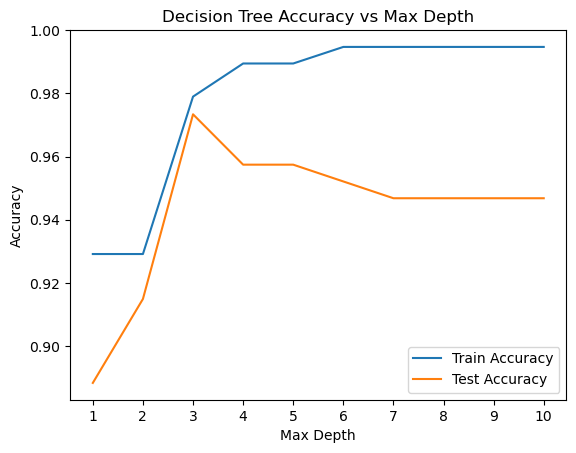

In [39]:
max_depth_values = list(range(1, 11))

train_accuracies = []
test_accuracies = []

for depth in max_depth_values:
    decision_tree_classifier = DecisionTreeClassifier(     criterion='entropy',min_impurity_decrease=0.01,min_samples_split=2,max_depth=depth,random_state=42)
    
    decision_tree_classifier.fit(features_train, labels_train)
    train_predictions = decision_tree_classifier.predict(features_train)
    test_predictions = decision_tree_classifier.predict(features_test)
    train_accuracy = accuracy_score(labels_train, train_predictions)
    test_accuracy = accuracy_score(labels_test, test_predictions)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)


plt.figure()
plt.plot(max_depth_values, train_accuracies, label='Train Accuracy')
plt.plot(max_depth_values, test_accuracies, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.xticks(max_depth_values)
plt.legend()

plt.show()

The optimal depth for the model is 3 as it is shown in the graph 

## 2. Display the top five most important features according to the model

In [38]:

feature_importances = decision_tree_classifier.feature_importances_

feature_importance_dataframe = pd.DataFrame({
    'feature_name': data.feature_names,
    'importance': feature_importances
})

top_five_features = feature_importance_dataframe.sort_values(
    by='importance',
    ascending=False
).head(5)

top_five_features

,feature_name,importance
7,mean concave points,0.631782
21,worst texture,0.098686
22,worst perimeter,0.096801
20,worst radius,0.072205
27,worst concave points,0.024734


## 3. how controlling model complexity affects overfitting

If we don't control the complexity of the model this will result in many splits which creates a tree with numerous
leaf nodes each including only one or few samples with a similar class. SUch tree would predict perfectly our train data but will fail in generalizing new data that is even similar to the trainning set.
<br>
## 4. how feature importance contributes to the interpretability of decision trees

# Q4 — Neural Network for Binary Classification 

## 1. Standardize the input features

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)


## 2. Train a neural network with at least one hidden layer and a sigmoid output unit.